In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

with open('results/debug_results.json') as f:
    data = json.load(f)

POINTS = [10, 20, 30, 40]
BLUE   = '#4472C4'
RED    = '#C0392B'
GRAY   = '#95A5A6'
GREEN  = '#27AE60'
CHANCE = 0.25  # random baseline per tier

# ── Extract per-fold choice rates and avg pts ─────────────────────────────
def extract(key):
    rows_by_fold = {}
    for row in data[key]:
        rows_by_fold.setdefault(row['fold'], []).append(row)

    fold_choice_rates = {pts: [] for pts in POINTS}
    fold_avg_pts      = []
    fold_optimal      = []

    for fi in sorted(rows_by_fold):
        fold_rows = rows_by_fold[fi]
        n = len(fold_rows)
        counts = {pts: 0 for pts in POINTS}
        pts_list, opt_list = [], []
        for r in fold_rows:
            pts = r['v1_pts']
            if pts in counts: counts[pts] += 1
            pts_list.append(pts)
            opt_list.append(pts == 40)
        for pts in POINTS:
            fold_choice_rates[pts].append(counts[pts] / n)
        fold_avg_pts.append(np.mean(pts_list))
        fold_optimal.append(np.mean(opt_list))

    return {
        'choice_mean': {pts: np.mean(fold_choice_rates[pts]) for pts in POINTS},
        'choice_sem':  {pts: np.std(fold_choice_rates[pts]) / 2 for pts in POINTS},  # /sqrt(4)
        'avg_pts':     fold_avg_pts,
        'optimal':     fold_optimal,
        'avg_pts_mean': np.mean(fold_avg_pts),
        'avg_pts_sem':  np.std(fold_avg_pts) / 2,
    }

base = extract('baseline')
modA = extract('model_a')
print('Baseline avg pts:', base['avg_pts_mean'])
print('Model A  avg pts:', modA['avg_pts_mean'])

Baseline avg pts: 37.083333333333336
Model A  avg pts: 34.270833333333336


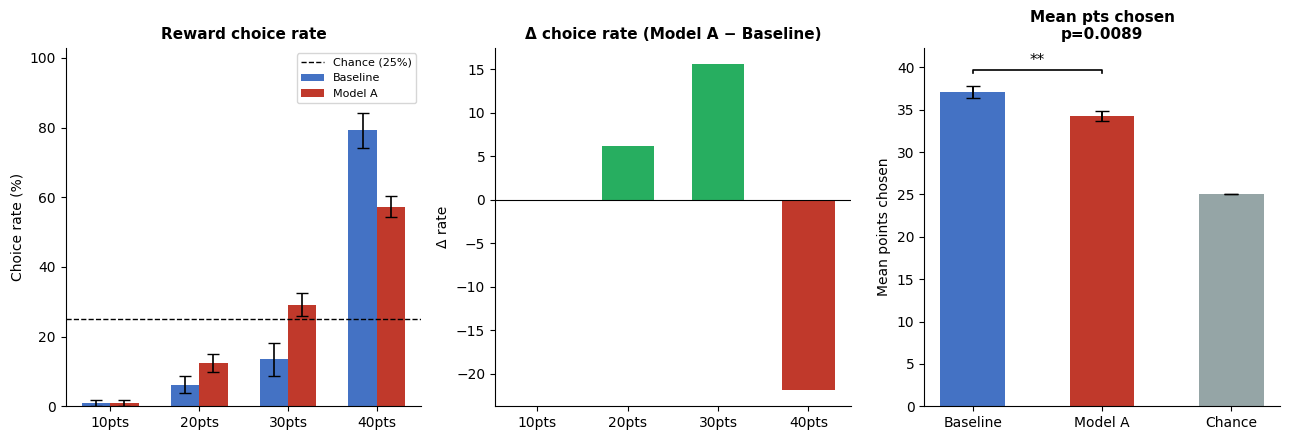

Saved → results/asdiv_model_a_results.png
Paired t-test: t=6.088, p=0.0089, sig=**


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
fig.patch.set_facecolor('white')

x      = np.arange(len(POINTS))
width  = 0.32
labels = [f'{p}pts' for p in POINTS]

# ── Panel 1: Reward choice rate ──────────────────────────────────────────
ax = axes[0]
b_means = [base['choice_mean'][p] * 100 for p in POINTS]
b_sems  = [base['choice_sem'][p]  * 100 for p in POINTS]
a_means = [modA['choice_mean'][p] * 100 for p in POINTS]
a_sems  = [modA['choice_sem'][p]  * 100 for p in POINTS]

ax.bar(x - width/2, b_means, width, color=BLUE, yerr=b_sems, capsize=4,
       error_kw={'linewidth': 1.2}, label='Baseline')
ax.bar(x + width/2, a_means, width, color=RED,  yerr=a_sems, capsize=4,
       error_kw={'linewidth': 1.2}, label='Model A')
ax.axhline(25, color='black', linestyle='--', linewidth=1, label='Chance (25%)')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Choice rate (%)')
ax.set_title('Reward choice rate', fontsize=11, fontweight='bold')
ax.set_ylim(0, max(max(b_means), max(a_means)) * 1.3)
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# ── Panel 2: Delta choice rate (Model A - Baseline) ──────────────────────
ax = axes[1]
deltas = [(modA['choice_mean'][p] - base['choice_mean'][p]) * 100 for p in POINTS]
colors = [GREEN if d >= 0 else RED for d in deltas]
ax.bar(x, deltas, width*1.8, color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Δ rate')
ax.set_title('Δ choice rate (Model A − Baseline)', fontsize=11, fontweight='bold')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# ── Panel 3: Mean pts chosen ─────────────────────────────────────────────
ax = axes[2]
conditions  = ['Baseline', 'Model A', 'Chance']
means       = [base['avg_pts_mean'], modA['avg_pts_mean'], 25.0]
sems        = [base['avg_pts_sem'],  modA['avg_pts_sem'],  0.0]
bar_colors  = [BLUE, RED, GRAY]

bars = ax.bar(conditions, means, color=bar_colors, width=0.5,
              yerr=sems, capsize=5, error_kw={'linewidth': 1.4})

# Significance bracket (Baseline vs Model A)
b_pts = base['avg_pts']
a_pts = modA['avg_pts']
t, p  = stats.ttest_rel(b_pts, a_pts)
sig   = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
y_top = max(means[0] + sems[0], means[1] + sems[1]) + 1.5
ax.plot([0, 0, 1, 1], [y_top, y_top+0.4, y_top+0.4, y_top], lw=1.2, c='black')
ax.text(0.5, y_top + 0.6, sig, ha='center', va='bottom', fontsize=11)
ptext = f'p={p:.4f}' if p >= 0.0001 else 'p<0.0001'
ax.set_title(f'Mean pts chosen\n{ptext}', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean points chosen')
ax.set_ylim(0, y_top + 3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
os.makedirs('results', exist_ok=True) if False else None
plt.savefig('results/asdiv_model_a_results.png', dpi=180, bbox_inches='tight')
plt.show()
print(f'Saved → results/asdiv_model_a_results.png')
print(f'Paired t-test: t={t:.3f}, p={p:.4f}, sig={sig}')

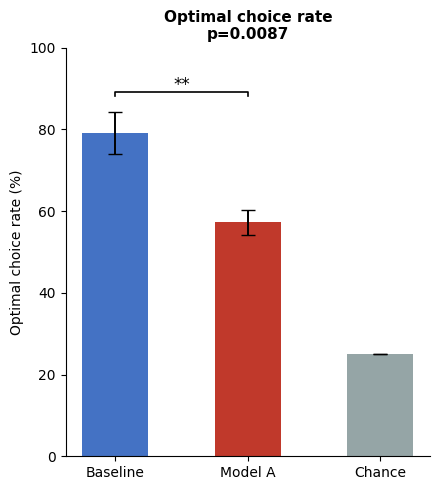

Baseline: 79.2±5.1%  |  Model A: 57.3±3.1%  |  Δ=-21.9%  |  ** (p=0.0087)


In [3]:
import json, numpy as np, matplotlib.pyplot as plt
from scipy import stats

with open("results/debug_results.json") as f:
    data = json.load(f)

def get_optimal_per_fold(key):
    rows_by_fold = {}
    for row in data[key]:
        rows_by_fold.setdefault(row["fold"], []).append(row)
    return [np.mean([r["v1_pts"] == 40 for r in rows_by_fold[fi]]) * 100
            for fi in sorted(rows_by_fold)]

base_opt = get_optimal_per_fold("baseline")
modA_opt = get_optimal_per_fold("model_a")

bm, bs = np.mean(base_opt), np.std(base_opt) / 2
am, as_ = np.mean(modA_opt), np.std(modA_opt) / 2
t, p = stats.ttest_rel(base_opt, modA_opt)
sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"

fig, ax = plt.subplots(figsize=(4.5, 5))
fig.patch.set_facecolor("white")

means  = [bm, am, 25.0]
sems   = [bs, as_, 0.0]
colors = ["#4472C4", "#C0392B", "#95A5A6"]
ax.bar(["Baseline", "Model A", "Chance"], means, color=colors, width=0.5,
       yerr=sems, capsize=5, error_kw={"linewidth": 1.4})

y_top = max(bm + bs, am + as_) + 4
ax.plot([0, 0, 1, 1], [y_top, y_top+1, y_top+1, y_top], lw=1.2, c="black")
ax.text(0.5, y_top + 1.5, sig, ha="center", fontsize=12)

ax.set_ylabel("Optimal choice rate (%)")
ax.set_title(f"Optimal choice rate\np={p:.4f}", fontsize=11, fontweight="bold")
ax.set_ylim(0, 100)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("results/asdiv_accuracy.png", dpi=180, bbox_inches="tight")
plt.show()
print(f"Baseline: {bm:.1f}±{bs:.1f}%  |  Model A: {am:.1f}±{as_:.1f}%  |  Δ={am-bm:+.1f}%  |  {sig} (p={p:.4f})")

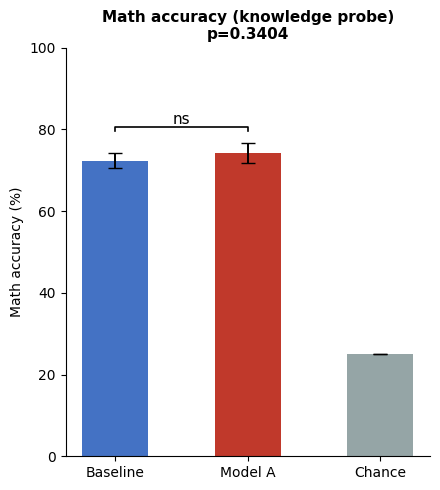

Baseline: 72.4±1.9%  |  Model A: 74.2±2.5%  |  Δ=+1.8%  |  ns (p=0.3404)


In [4]:
import json, re
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

with open("results/accuracy_results.json") as f:
    data = json.load(f)

def extract_last_number(text):
    text = text.replace(",", "").replace("$", "")
    nums = re.findall(r'-?\d+\.?\d*', text)
    return float(nums[-1]) if nums else None

def is_correct(pred, gold):
    ref_nums = re.findall(r'-?\d+\.?\d*', str(gold).replace(",", ""))
    if not ref_nums or pred is None: return False
    ref = float(ref_nums[0])
    return abs(pred - ref) <= 0.02 * max(abs(ref), 1)

def get_fold_accs(key):
    rows_by_fold = {}
    for row in data[key]["rows"]:
        rows_by_fold.setdefault(row["fold"], []).append(row)
    return [np.mean([is_correct(extract_last_number(r["response"]), r["answer"])
                     for r in rows_by_fold[fi]]) * 100
            for fi in sorted(rows_by_fold)]

base_accs = get_fold_accs("baseline")
modA_accs = get_fold_accs("model_a")

bm, bs = np.mean(base_accs), np.std(base_accs) / 2
am, as_ = np.mean(modA_accs), np.std(modA_accs) / 2
t, p = stats.ttest_rel(base_accs, modA_accs)
sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"

fig, ax = plt.subplots(figsize=(4.5, 5))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

means  = [bm, am, 25.0]
sems   = [bs, as_, 0.0]
colors = ["#4472C4", "#C0392B", "#95A5A6"]
ax.bar(["Baseline", "Model A", "Chance"], means, color=colors, width=0.5,
       yerr=sems, capsize=5, error_kw={"linewidth": 1.4, "zorder": 5})

y_top = max(bm + bs, am + as_) + 3
ax.plot([0, 0, 1, 1], [y_top, y_top + 0.8, y_top + 0.8, y_top], lw=1.2, c="black")
ax.text(0.5, y_top + 1, sig, ha="center", va="bottom", fontsize=11)

ax.set_ylabel("Math accuracy (%)")
ax.set_ylim(0, 100)
ax.set_title(f"Math accuracy (knowledge probe)\np={p:.4f}", fontsize=11, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("results/accuracy_plot.png", dpi=180, bbox_inches="tight")
plt.show()
print(f"Baseline: {bm:.1f}±{bs:.1f}%  |  Model A: {am:.1f}±{as_:.1f}%  |  Δ={am-bm:+.1f}%  |  {sig} (p={p:.4f})")